In [1]:
# ============================================================
# CELL 1: Import & Setup
# ============================================================
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)

os.makedirs('outputs', exist_ok=True)
os.makedirs('data', exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

print("Setup OK")

Setup OK


In [2]:
# ============================================================
# CELL 2: Load Amazon Stock Price
# ============================================================
AMZN_PATH = 'data/AMZN.csv'   # đổi tên nếu file bạn khác
df_amzn = pd.read_csv(AMZN_PATH)
print("Shape:", df_amzn.shape)
print(df_amzn.head())
print(df_amzn.dtypes)

Shape: (6684, 7)
         Date      Open      High       Low     Close  Adj Close      Volume
0  1997-05-15  0.121875  0.125000  0.096354  0.097917   0.097917  1443120000
1  1997-05-16  0.098438  0.098958  0.085417  0.086458   0.086458   294000000
2  1997-05-19  0.088021  0.088542  0.081250  0.085417   0.085417   122136000
3  1997-05-20  0.086458  0.087500  0.081771  0.081771   0.081771   109344000
4  1997-05-21  0.081771  0.082292  0.068750  0.071354   0.071354   377064000
Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume']

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64


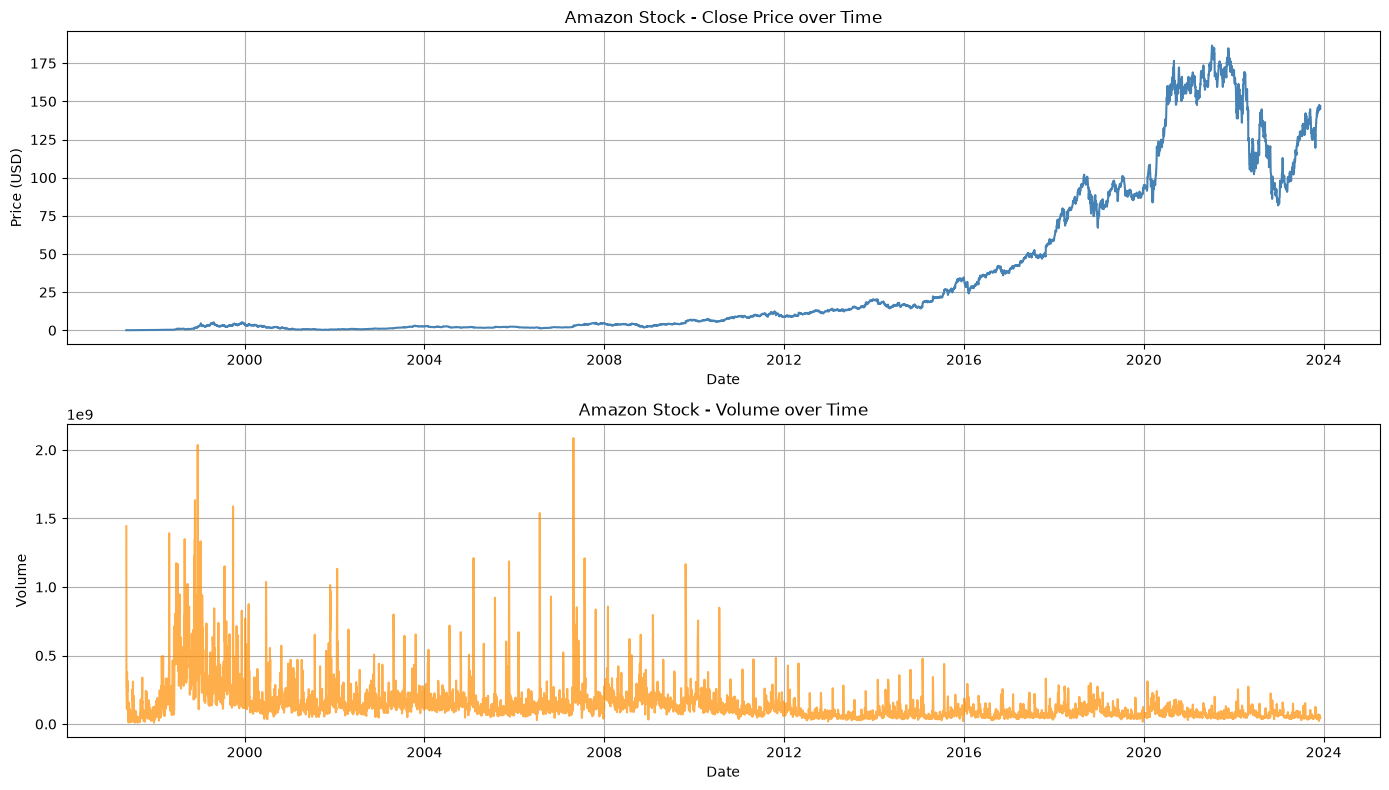

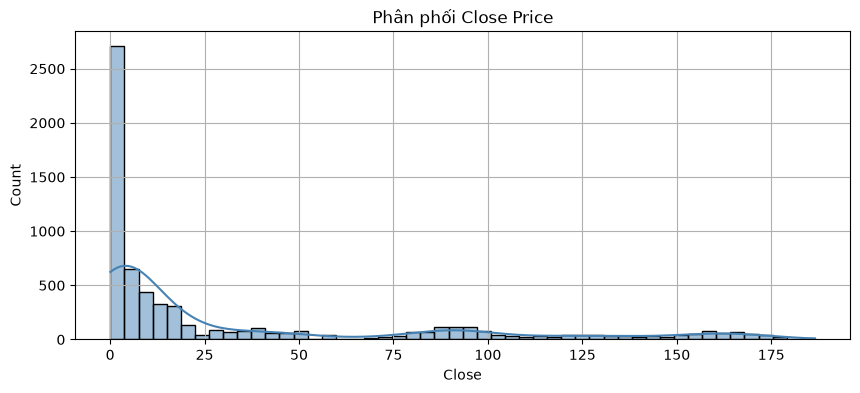


Số phiên: 6684
Khoảng thời gian: 1997-05-15 00:00:00+00:00 → 2023-12-05 00:00:00+00:00
Close range: 0.07 → 186.57


In [3]:
# ============================================================
# CELL 3: EDA - Amazon Stock
# ============================================================
# Chuẩn hóa tên cột (một số file có 'Adj Close' hoặc 'Adj_Close')
df_amzn.columns = [c.strip().replace(' ', '_') for c in df_amzn.columns]
print("Columns:", df_amzn.columns.tolist())

# Parse date
df_amzn['Date'] = pd.to_datetime(df_amzn['Date'], utc=True)
df_amzn = df_amzn.sort_values('Date').reset_index(drop=True)

# Kiểm tra missing
print("\nMissing values:")
print(df_amzn.isna().sum())

# Drop missing (thường không có)
df_amzn = df_amzn.dropna().reset_index(drop=True)

# Plot giá theo thời gian
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df_amzn['Date'], df_amzn['Close'], color='steelblue')
axes[0].set_title('Amazon Stock - Close Price over Time')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Price (USD)')

axes[1].plot(df_amzn['Date'], df_amzn['Volume'], color='darkorange', alpha=0.7)
axes[1].set_title('Amazon Stock - Volume over Time')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Volume')
plt.tight_layout()
plt.savefig('outputs/01_amzn_price_volume.png', dpi=200)
plt.show()

# Phân phối Close
plt.figure(figsize=(10, 4))
sns.histplot(df_amzn['Close'], bins=50, kde=True, color='steelblue')
plt.title('Phân phối Close Price')
plt.savefig('outputs/01_amzn_close_dist.png', dpi=200)
plt.show()

print(f"\nSố phiên: {len(df_amzn)}")
print(f"Khoảng thời gian: {df_amzn['Date'].min()} → {df_amzn['Date'].max()}")
print(f"Close range: {df_amzn['Close'].min():.2f} → {df_amzn['Close'].max():.2f}")

In [4]:
# ============================================================
# CELL 4: Preprocessing Amazon Stock
# ============================================================
# Feature engineering: 5 features
df_a = df_amzn[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
df_a['Volume'] = np.log1p(df_a['Volume'])  # log1p vì volume lệch phải

features_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
target_col = 'Close'

# Chia theo thời gian 70/15/15
n = len(df_a)
n_train = int(n * 0.7)
n_val = int(n * 0.15)
train_df = df_a.iloc[:n_train].copy()
val_df   = df_a.iloc[n_train:n_train + n_val].copy()
test_df  = df_a.iloc[n_train + n_val:].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Fit scaler CHỈ trên train
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df[features_cols] = x_scaler.fit_transform(train_df[features_cols])
val_df[features_cols]   = x_scaler.transform(val_df[features_cols])
test_df[features_cols]  = x_scaler.transform(test_df[features_cols])

train_df[['Close_scaled']] = y_scaler.fit_transform(train_df[[target_col]])
val_df[['Close_scaled']]   = y_scaler.transform(val_df[[target_col]])
test_df[['Close_scaled']]  = y_scaler.transform(test_df[[target_col]])

print("Scaled x range:", train_df[features_cols].values.min(), train_df[features_cols].values.max())


Train: 4678 | Val: 1002 | Test: 1004
Scaled x range: 0.0 1.0


In [5]:
# ============================================================
# CELL 5: Tạo sliding window cho AMZN
# ============================================================
WINDOW = 30   # 30 phiên quá khứ

def make_sequences(features, targets, window):
    """features: (N, F), targets: (N,) -> X: (N-window, window, F), y: (N-window,)"""
    X, y = [], []
    for i in range(len(features) - window):
        X.append(features[i:i+window])
        y.append(targets[i+window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Train (dùng cả val features để dự đoán liên tục)
def make_seq_from_df(df, window):
    f = df[features_cols].values.astype(np.float32)
    t = df['Close_scaled'].values.astype(np.float32)
    return make_sequences(f, t, window)

X_train, y_train = make_seq_from_df(train_df, WINDOW)
X_val,   y_val   = make_seq_from_df(val_df, WINDOW)
X_test,  y_test  = make_seq_from_df(test_df, WINDOW)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")

# Lưu
np.savez('data/amzn_processed.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test,
         y_mean=y_scaler.data_min_, y_scale=y_scaler.data_range_)
print("Đã lưu data/amzn_processed.npz")

X_train: (4648, 30, 5) | y_train: (4648,)
X_val  : (972, 30, 5)   | y_val  : (972,)
X_test : (974, 30, 5)  | y_test : (974,)
Đã lưu data/amzn_processed.npz


In [6]:
# ============================================================
# CELL 6: Load Online Retail II
# ============================================================
RETAIL_PATH = 'data/online_retail_II.xlsx'
df1 = pd.read_excel(RETAIL_PATH, sheet_name='Year 2009-2010')
df2 = pd.read_excel(RETAIL_PATH, sheet_name='Year 2010-2011')
df_r = pd.concat([df1, df2], ignore_index=True)

print("Shape:", df_r.shape)
print(df_r.head())
print(df_r.dtypes)

Shape: (1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID        

In [7]:
# ============================================================
# CELL 7: Clean Retail
# ============================================================
df_r.columns = [c.strip().replace(' ', '') for c in df_r.columns]
print("Columns:", df_r.columns.tolist())

# Bỏ missing Customer ID
df_r = df_r.dropna(subset=['CustomerID']).reset_index(drop=True)
df_r['CustomerID'] = df_r['CustomerID'].astype(int)

# Bỏ Quantity <= 0 (hàng trả lại) và Price <= 0
df_r = df_r[(df_r['Quantity'] > 0) & (df_r['Price'] > 0)].reset_index(drop=True)

# Parse date
df_r['InvoiceDate'] = pd.to_datetime(df_r['InvoiceDate'])
df_r['TotalPrice'] = df_r['Quantity'] * df_r['Price']

print(f"\nSố giao dịch hợp lệ: {len(df_r):,}")
print(f"Số khách hàng: {df_r['CustomerID'].nunique():,}")
print(f"Khoảng thời gian: {df_r['InvoiceDate'].min()} → {df_r['InvoiceDate'].max()}")

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']

Số giao dịch hợp lệ: 805,549
Số khách hàng: 5,878
Khoảng thời gian: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


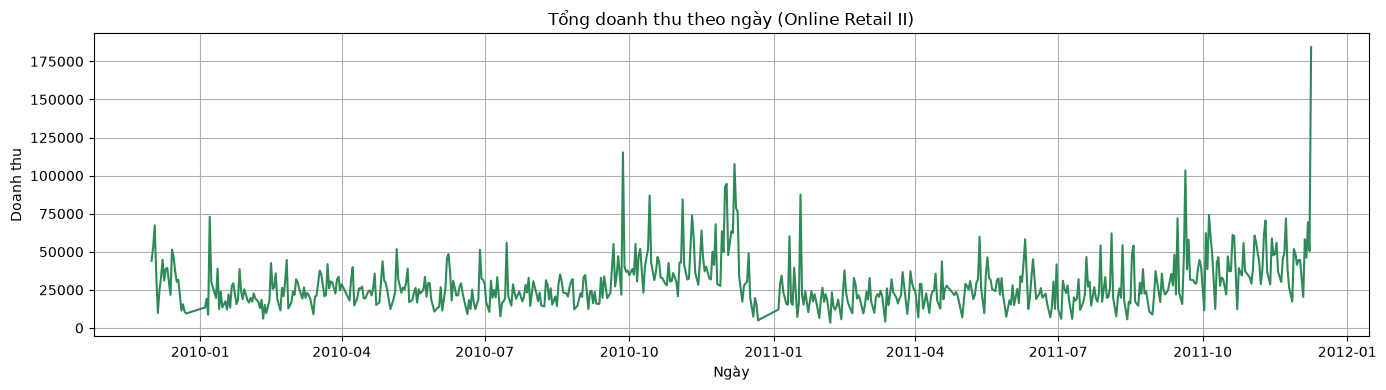

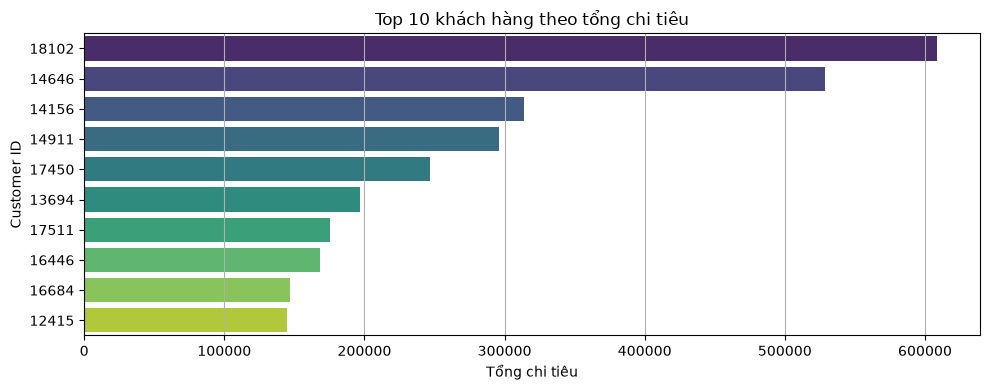

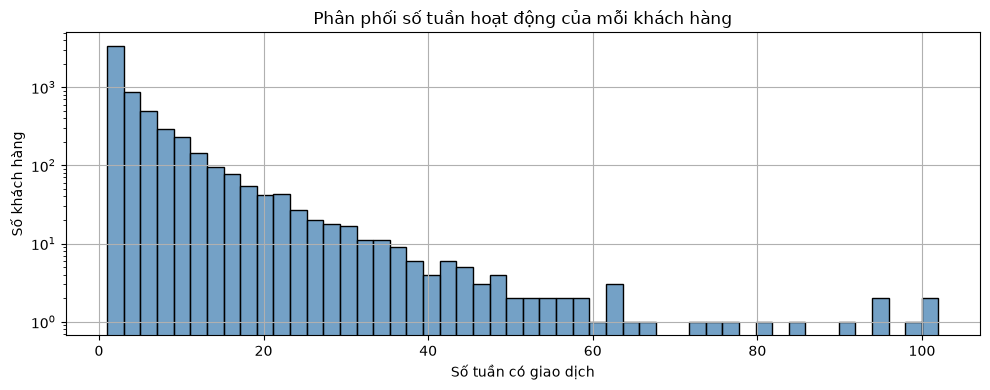


Thống kê số tuần hoạt động:
count    5878.000000
mean        5.335488
std         7.625223
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max       102.000000
Name: YearWeek, dtype: float64


In [8]:
# ============================================================
# CELL 8: EDA Retail
# ============================================================
# Doanh thu theo ngày
daily_rev = df_r.groupby(df_r['InvoiceDate'].dt.date)['TotalPrice'].sum()
plt.figure(figsize=(14, 4))
plt.plot(pd.to_datetime(daily_rev.index), daily_rev.values, color='seagreen')
plt.title('Tổng doanh thu theo ngày (Online Retail II)')
plt.xlabel('Ngày'); plt.ylabel('Doanh thu')
plt.tight_layout()
plt.savefig('outputs/01_retail_daily_revenue.png', dpi=200)
plt.show()

# Top 10 khách hàng theo tổng chi tiêu
top_cust = df_r.groupby('CustomerID')['TotalPrice'].sum().nlargest(10)
plt.figure(figsize=(10, 4))
sns.barplot(x=top_cust.values, y=top_cust.index.astype(str), palette='viridis')
plt.title('Top 10 khách hàng theo tổng chi tiêu')
plt.xlabel('Tổng chi tiêu'); plt.ylabel('Customer ID')
plt.tight_layout()
plt.savefig('outputs/01_retail_top_customers.png', dpi=200)
plt.show()

# Phân phối số tuần hoạt động / khách
df_r['YearWeek'] = df_r['InvoiceDate'].dt.to_period('W')
active_weeks = df_r.groupby('CustomerID')['YearWeek'].nunique()
plt.figure(figsize=(10, 4))
sns.histplot(active_weeks, bins=50, kde=False, color='steelblue')
plt.title('Phân phối số tuần hoạt động của mỗi khách hàng')
plt.xlabel('Số tuần có giao dịch'); plt.ylabel('Số khách hàng')
plt.yscale('log')
plt.tight_layout()
plt.savefig('outputs/01_retail_active_weeks.png', dpi=200)
plt.show()

print("\nThống kê số tuần hoạt động:")
print(active_weeks.describe())

In [11]:
# ============================================================
# CELL 9: Tạo sequence cấp độ khách hàng (weekly)
# ============================================================
# Gom theo CustomerID + YearWeek
weekly = df_r.groupby(['CustomerID', 'YearWeek']).agg(
    total_qty=('Quantity', 'sum'),
    total_price=('TotalPrice', 'sum'),
    n_invoices=('Invoice', 'nunique'),
    n_products=('StockCode', 'nunique'),
).reset_index()

# 1. Tạo danh sách tất cả các tuần từ đầu đến cuối dataset
all_weeks = pd.period_range(
    start=df_r['InvoiceDate'].min(), 
    end=df_r['InvoiceDate'].max(), 
    freq='W'
)

# 2. Tạo danh sách tất cả khách hàng
all_customers = df_r['CustomerID'].unique()

# 3. Tạo MultiIndex đầy đủ (mọi khách hàng x mọi tuần)
full_idx = pd.MultiIndex.from_product(
    [all_customers, all_weeks], 
    names=['CustomerID', 'YearWeek']
)

# 4. Reindex để điền các tuần thiếu (khách không mua) bằng 0
weekly_full = weekly.set_index(['CustomerID', 'YearWeek']) \
                    .reindex(full_idx) \
                    .fillna(0) \
                    .reset_index()

# 5. Sắp xếp lại theo khách hàng và tuần
weekly_full = weekly_full.sort_values(['CustomerID', 'YearWeek']).reset_index(drop=True)

# Số tuần tối thiểu để đưa vào mô hình
MIN_WEEKS = 12
WINDOW_R = 10   # 10 tuần quá khứ

# Build timeline của mỗi khách hàng
cust_groups = weekly_full.groupby('CustomerID')

X_r_list, y_r_list = [], []

for cid, grp in cust_groups:
    grp = grp.sort_values('YearWeek').reset_index(drop=True)
    if len(grp) < MIN_WEEKS:
        continue
    feats = grp[['total_qty', 'total_price', 'n_invoices', 'n_products']].values.astype(np.float32)
    for i in range(len(feats) - WINDOW_R):
        X_r_list.append(feats[i:i+WINDOW_R])
        # Target: có mua hàng trong tuần tiếp theo không (binary)
        # Bây giờ total_qty có thể = 0 nên nhãn sẽ có cả 0 và 1
        next_active = 1 if grp['total_qty'].iloc[i+WINDOW_R] > 0 else 0
        y_r_list.append(next_active)

X_r = np.array(X_r_list, dtype=np.float32)
y_r = np.array(y_r_list, dtype=np.float32)

print(f"X_r shape: {X_r.shape}, y_r shape: {y_r.shape}")
print(f"Tỷ lệ positive: {y_r.mean():.4f}")
print(f"Tỷ lệ negative: {1 - y_r.mean():.4f}")

X_r shape: (564288, 10, 4), y_r shape: (564288,)
Tỷ lệ positive: 0.0514
Tỷ lệ negative: 0.9486


In [12]:
# ============================================================
# CELL 10: Chia train/val/test cho Retail
# ============================================================
from sklearn.model_selection import train_test_split

# 1. Chia Train (70%) và Temp (30%)
X_r_train, X_temp, y_r_train, y_temp = train_test_split(
    X_r, y_r, test_size=0.3, random_state=SEED, stratify=y_r
)

# 2. Chia Temp thành Val (15%) và Test (15%)
X_r_val, X_r_test, y_r_val, y_r_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Train: {X_r_train.shape} | Val: {X_r_val.shape} | Test: {X_r_test.shape}")
print(f"Positive rate - Train: {y_r_train.mean():.4f} | Val: {y_r_val.mean():.4f} | Test: {y_r_test.mean():.4f}")

# Lưu
np.savez('data/retail_processed.npz',
         X_train=X_r_train, y_train=y_r_train,
         X_val=X_r_val, y_val=y_r_val,
         X_test=X_r_test, y_test=y_r_test)
print("Đã lưu data/retail_processed.npz")

Train: (395001, 10, 4) | Val: (84643, 10, 4) | Test: (84644, 10, 4)
Positive rate - Train: 0.0514 | Val: 0.0514 | Test: 0.0514
Đã lưu data/retail_processed.npz
